<a href="https://colab.research.google.com/github/Fahrizp24/PCVK_Ganjil_2025/blob/main/latihan_integrasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow  # for image display
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt


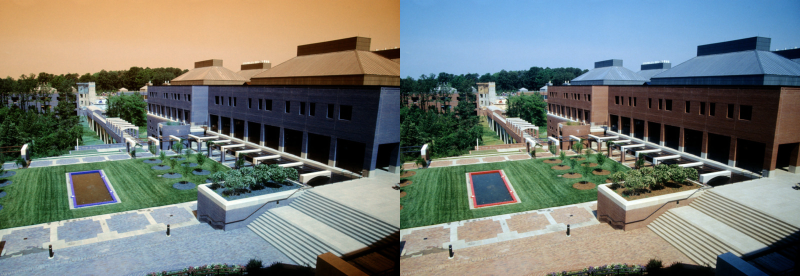

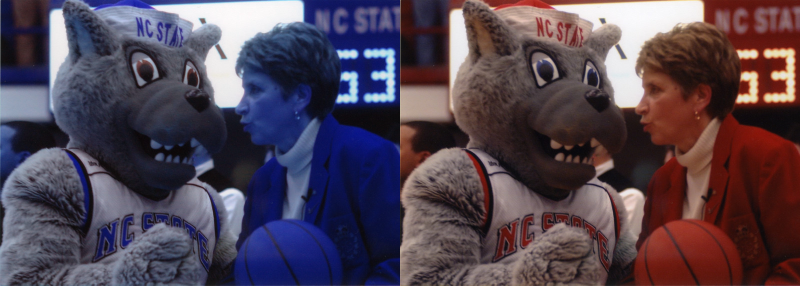

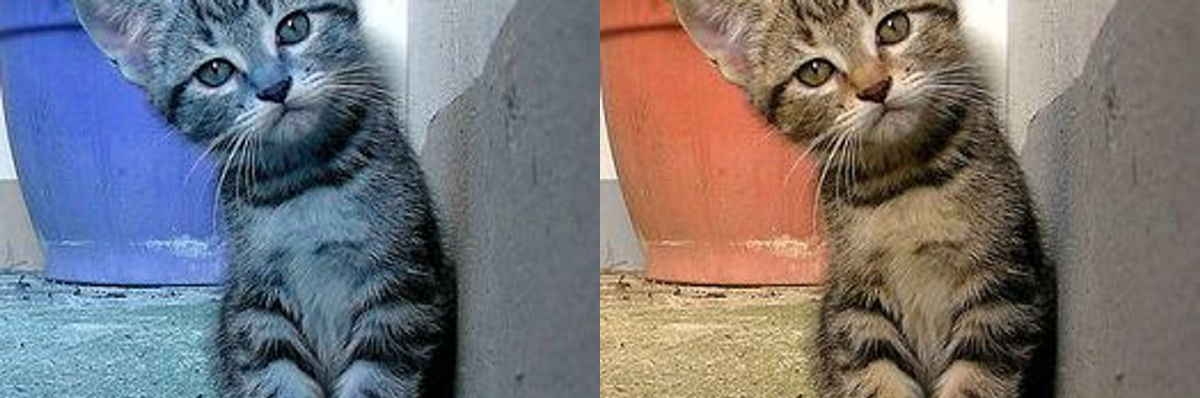

In [3]:
# Membuat list untuk menyimpan URL dari beberapa image
urls = [
    "https://iiif.lib.ncsu.edu/iiif/0052574/full/800,/0/default.jpg",
    "https://iiif.lib.ncsu.edu/iiif/0016007/full/800,/0/default.jpg",
    "https://www.lovemeow.com/media-library/image.jpg?id=4140709&width=1200&height=800&quality=85&coordinates=0%2C72%2C0%2C73"
]

# Baca dan tampilkan image
# Loop pada tiap URL image, beberapa image dapat disimpan pada list
for url in urls:
    image = io.imread(url)                        # read image
    image = cv.resize(image, (0, 0), fx=0.5, fy=0.5)  # resize image to half size
    image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)    # convert color to RGB
    final_frame = cv.hconcat([image, image_2])        # concatenate image
    cv2_imshow(final_frame)                           # show image
    print('\n')


resolusi image: tinggi x lebar =  398  x  600


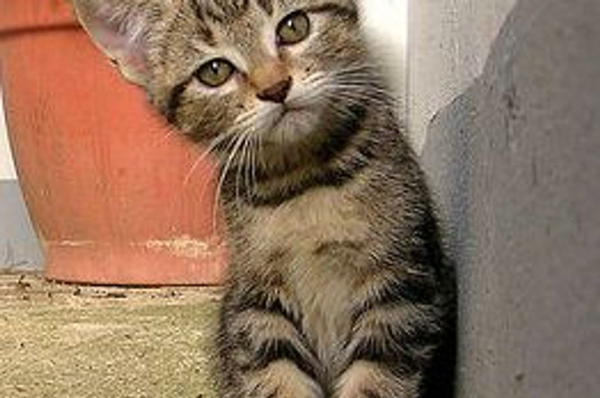

In [4]:
# Melihat ukuran file image
tinggi = image_2.shape[0]   # ambil ukuran tinggi (rows)
lebar = image_2.shape[1]    # ambil ukuran lebar (columns)

# Tampilkan resolusi image
print("resolusi image: tinggi x lebar = ", tinggi, " x ", lebar)

# Tampilkan image
cv2_imshow(image_2)


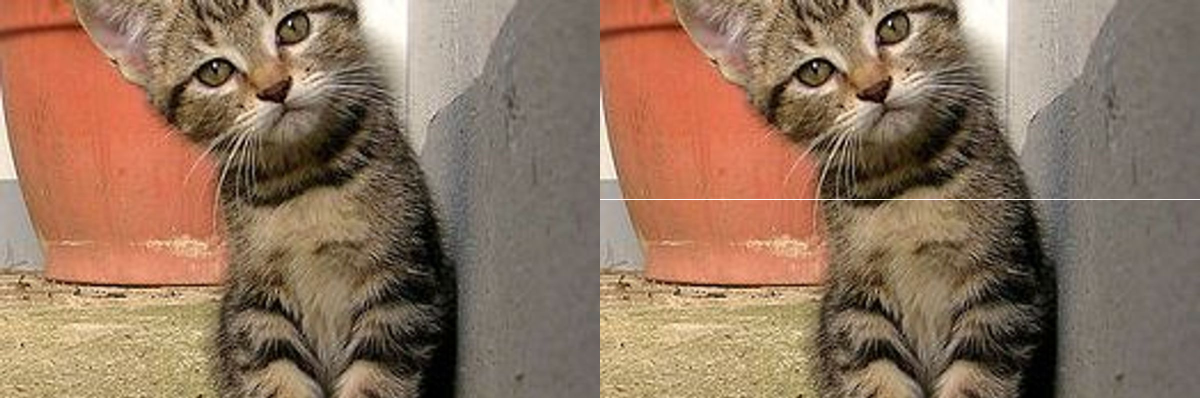

In [5]:
# Konversi warna dari BGR ke RGB
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# Membuat garis horizontal di tengah image
for y in range(lebar):
    image_3[int((tinggi)/2), y] = [255, 255, 255]   # warna putih (R=255, G=255, B=255)

# Menggabungkan citra asli dan citra dengan garis
final_frame = cv.hconcat((image_2, image_3))

# Menampilkan hasil
cv2_imshow(final_frame)


1.	Jelaskan, mengapa pada modul praktikum ini eksekusi kode Python dilakukan menggunakan Google Colab?

jawab:

karena phyton pada  Google Colab sangat praktis, gratis, ringan dijalankan, serta mendukung library yang dibutuhkan

2. Jelaskan mengenai kegunaan setiap library pada praktikum langkah ke delapan? Apakah semua library tersebut harus digunakan dalam praktikum sesi ini?

jawab:


3.	Pada uji coba langkah ke-9 terdapat potongan kode program sebagai berikut : image = cv.resize(image, (0, 0), fx=0.5, fy=0.5) Apa kegunaan kode program tersebut?dan apa pengaruhnya jika tidak dilakukan?
jawab: Kode tersebut berfungsi untuk mengurangi ukuran menjadi 50% dari ukuran awal, sehingga lebih ringan ditampilkan atau diproses pada langkah berikutnya.

4.	Perhatikan potongan kode progam berikut : Apakah kegunaan kode [255,255,255] ? Jelaskan!
jawab: Kode [255,255,255] digunakan untuk mengganti warna pixel menjadi putih dan membuay garis horizontal berwarna putih di tengah gambar dengan cara mengubah warna semua pixel pada koordinat y.

5.	Jelaskan keterkaitan antara pixel dan juga resolusi gambar yang tinggi ataupun rendah!
jawab: Pixel adalah elemen pembentuk gambar digital, sedangkan resolusi menunjukkan jumlah pixel yang menyusun gambar. Semakin tinggi resolusi, semakin banyak pixel yang membentuk gambar, sehingga kualitas visualnya lebih baik. Sebaliknya, semakin rendah resolusi, jumlah pixel semakin sedikit dan kualitas gambar menurun.





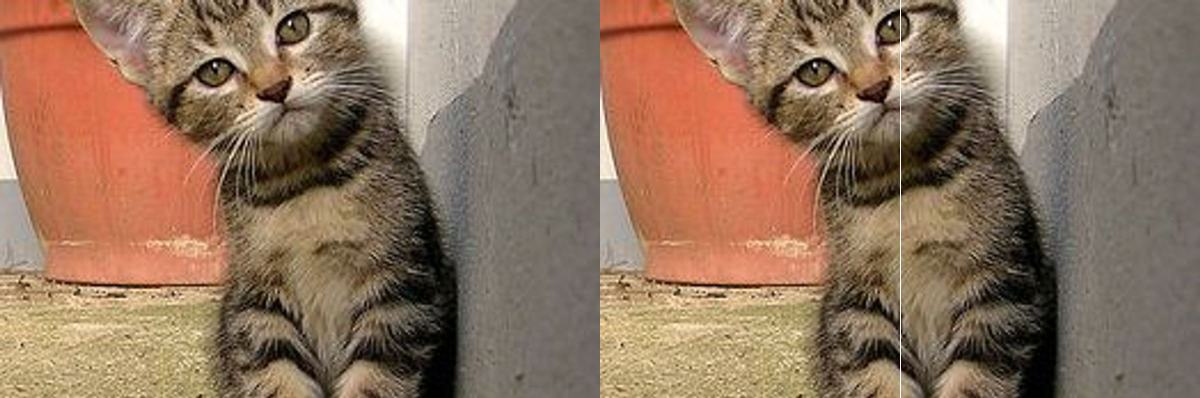

In [12]:
image_4 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

for y in range(tinggi):
    image_4[y, int(lebar/2)] = [255, 255, 255]   # warna putih (R=255, G=255, B=255)

final_frame = cv.hconcat((image_2, image_4))

cv2_imshow(final_frame)


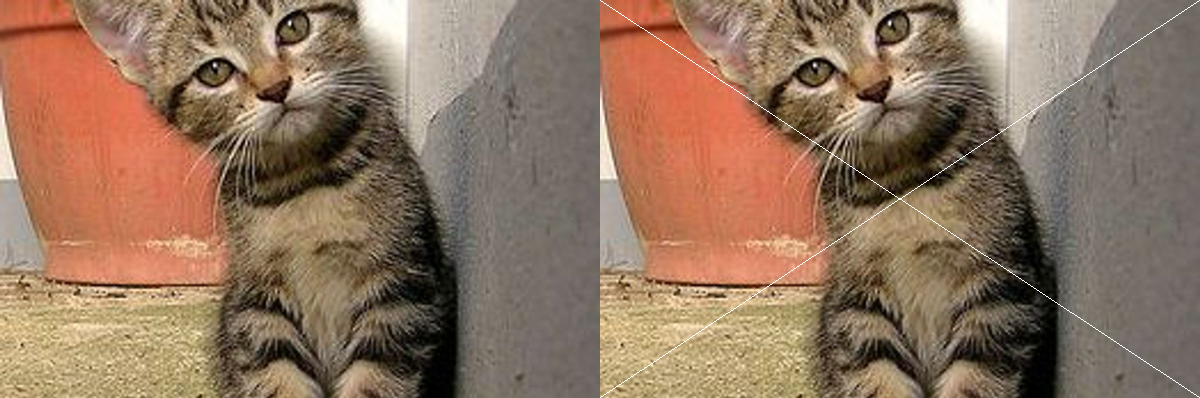

In [17]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)


# Garis diagonal(kiri-atas ke kanan-bawah)
for x in range(lebar):
    y = int(round((tinggi - 1) * x / (lebar - 1))) if lebar > 1 else 0
    image_3[y, x] = [255, 255, 255]

# Garis diagona (kanan-atas ke kiri-bawah)
for x in range(lebar):
    y = (tinggi - 1) - int(round((tinggi - 1) * x / (lebar - 1))) if lebar > 1 else 0
    image_3[y, x] = [255, 255, 255]

# Menggabungkan & menampilkan
final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)


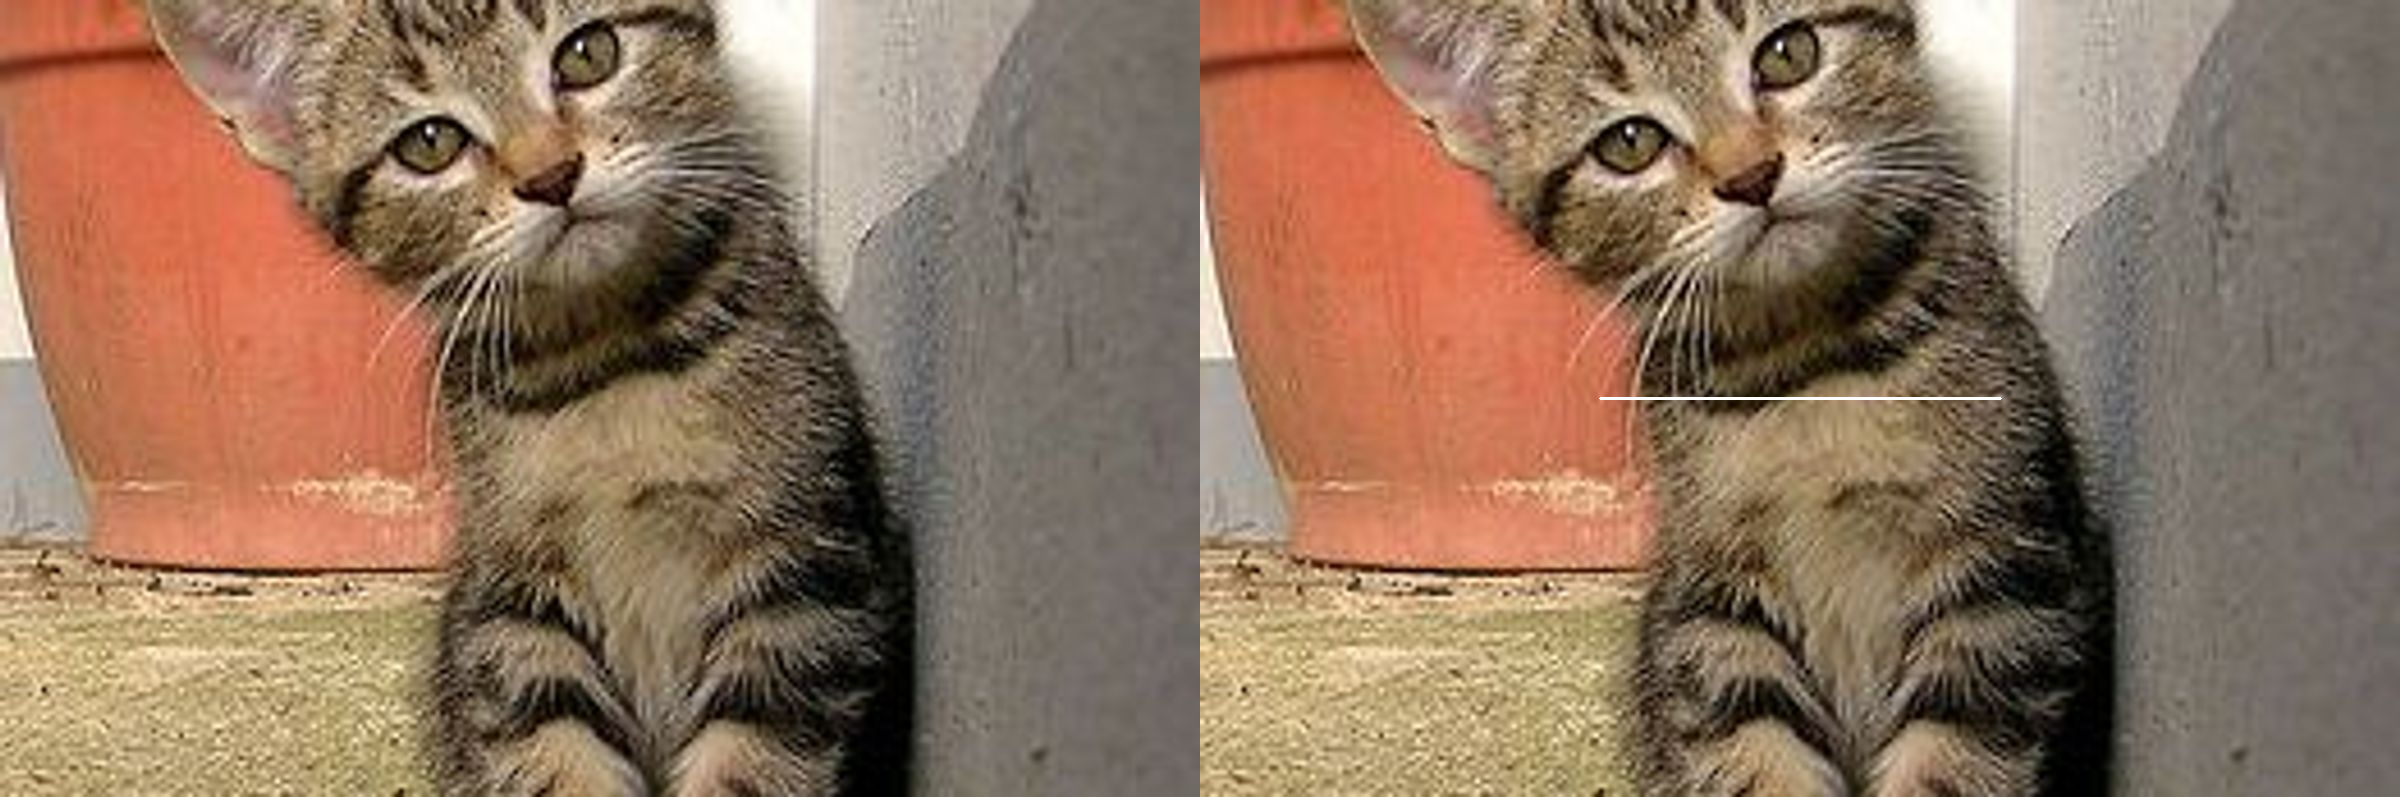

In [37]:
image_6 = image_3.copy()

tinggi, lebar, _ = image_3.shape

# Koordinat garis horizontal di tengah
y_tengah = tinggi // 2

# Tentukan panjang garis (misalnya 1/3 dari lebar gambar)
panjang_garis = lebar // 3

# Titik awal dan akhir garis (diletakkan di tengah gambar)
x_awal = (lebar - panjang_garis) // 2
x_akhir = x_awal + panjang_garis

cv.line(image_6, (x_awal, y_tengah), (x_akhir, y_tengah), (255, 255, 255), 2)

final_frame = cv.hconcat([image_3, image_6])

cv2_imshow(final_frame)


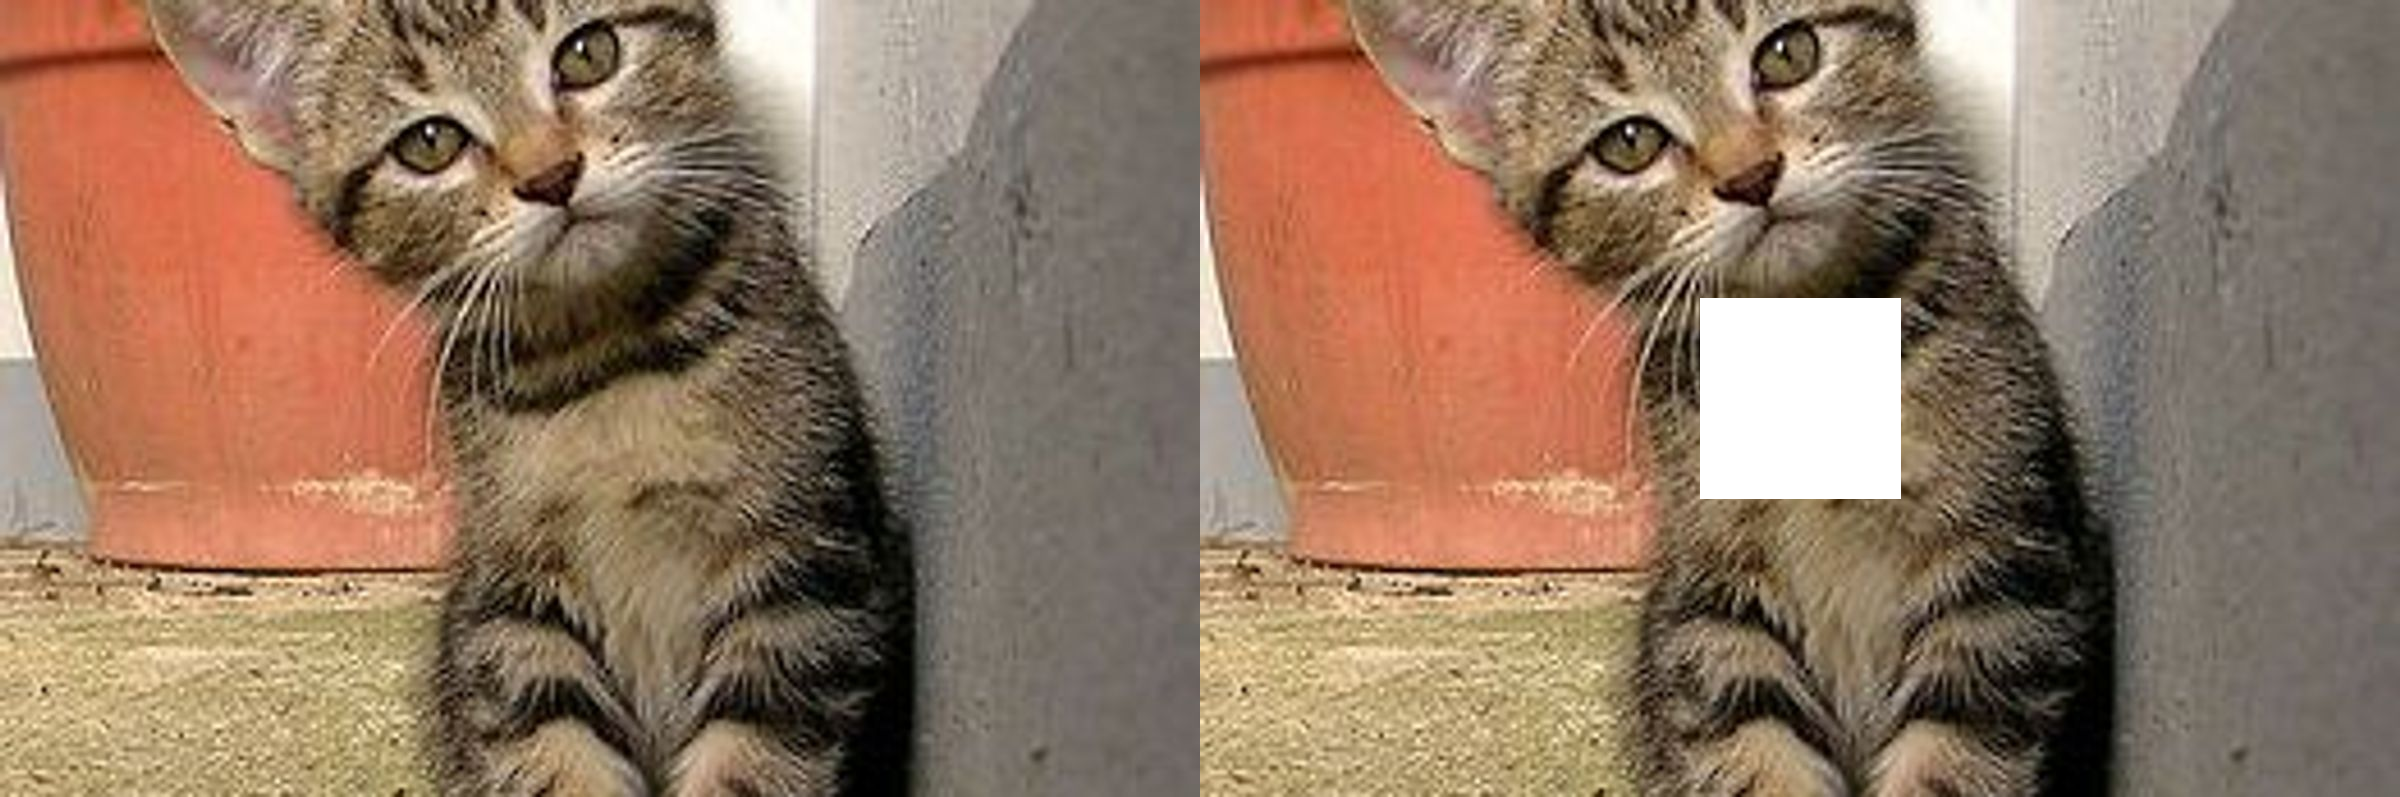

In [41]:
image_7 = image_3.copy()

tinggi, lebar, _ = image_3.shape

kotak = 200

x_tengah = lebar // 2
y_tengah = tinggi // 2

x1 = x_tengah - kotak // 2
y1 = y_tengah - kotak // 2
x2 = x_tengah + kotak // 2
y2 = y_tengah + kotak // 2

cv.rectangle(image_7, (x1, y1), (x2, y2), (255, 255, 255), -1)

final_frame = cv.hconcat([image_3, image_7])

cv2_imshow(final_frame)
